In [1]:
import random
import pandas as pd
import numpy as np
import pwlf

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_5min"

df = pd.read_csv(f'../datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.9 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [2]:
def build_min_vectors_by_slopes(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            x = np.arange(N + 1)
            y = df.iloc[i-N:i + 1]['open'].values
            model = pwlf.PiecewiseLinFit(x, y)
            _ = model.fit(4)
            vectors.append(model.slopes)
    return np.array(vectors)

def build_max_vectors_by_slopes(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_max'] or take_all:
            x = np.arange(N + 1)
            y = df.iloc[i-N:i + 1]['open'].values
            model = pwlf.PiecewiseLinFit(x, y)
            _ = model.fit(4)
            vectors.append(model.slopes)
    return np.array(vectors)

X_train_min = build_min_vectors_by_slopes(df_train, N)
X_train_max = build_max_vectors_by_slopes(df_train, N)
print(X_train_min.shape, X_train_max.shape)

(91, 4) (105, 4)


***Минимумы***

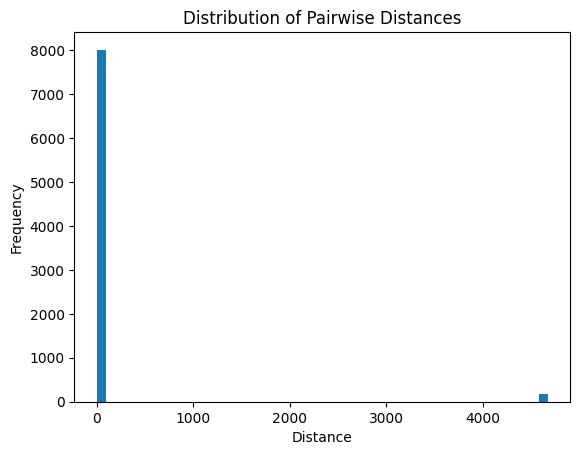

In [3]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_min)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

Как можно заметить, расстояния нерепрезентативны. Это происходит из-за того, что наклоны прямых могут иметь очень разные масштаб, а также могут быть выбросы.

Допустим, для двух экстремумов:
$V1 = [8500, -4300, 1.0]$

$V2 = [8600, -4400, 1.5]$

Евклидово расстояние:
$d = sqrt((8600-8500)^2 + (-4400-(-4300))^2 + (1.5-1.0)^2)
  = sqrt(10000 + 10000 + 0.25)
  ≈ 141$
  
Третий признак (slope=1.0) вообще не влияет на расстояние, потому что первые два признака на порядки больше. Фактически кластеризация идёт только по двум числам, а третье игнорируется.

Плюс, pwlf иногда строит прямые с очень большими по модулю наклонами и очень близкими концами, хотя можно отдалить концы, и тогда наклоны станут адекватнее (это в нашем случае и есть выбросы)

In [4]:
lower = np.percentile(X_train_min, 3, axis=0)
upper = np.percentile(X_train_min, 97, axis=0)
print("Lower percentiles (3%):", lower)
print("Upper percentiles (97%):", upper)

mask = np.all((X_train_min >= lower) & (X_train_min <= upper), axis=1)
X_train_clean = X_train_min[mask]

print(f"Осталось {mask.sum()} из {len(mask)} точек")

Lower percentiles (3%): [-0.54449434 -3.15192402 -2.54624597 -2.91472654]
Upper percentiles (97%): [ 1.10202272e+00  5.00472857e+00  3.27666788e+00 -5.16622854e-04]
Осталось 68 из 91 точек


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

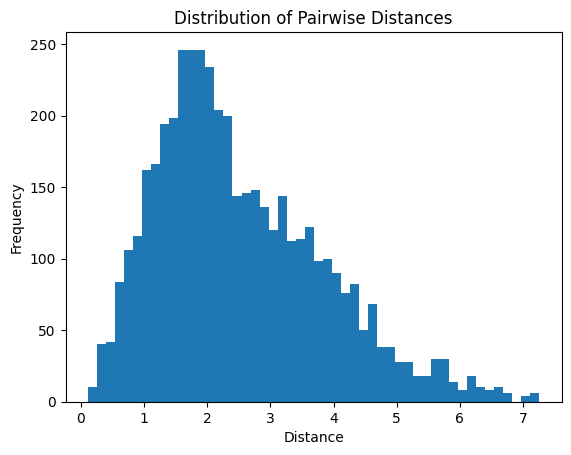

In [6]:
distances = euclidean_distances(X_train_scaled)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [7]:
print("Max values:")
print(np.max(X_train_scaled, axis=0))
print("Min values:")
print(np.min(X_train_scaled, axis=0))
print("Median values:")
print(np.median(X_train_scaled, axis=0))

Max values:
[3.85067279 4.55339449 3.9503793  0.91062828]
Min values:
[-1.9924422  -2.17890273 -3.01002039 -3.56609986]
Median values:
[-0.0872405   0.03254695 -0.12498217  0.36998355]


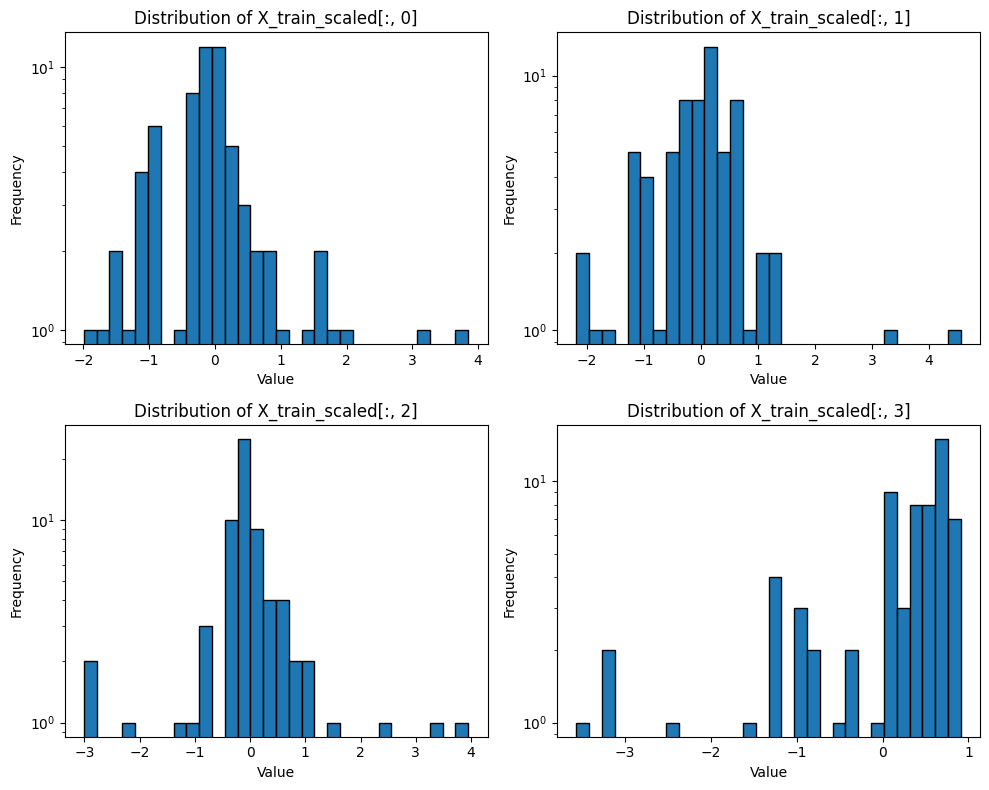

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].hist(X_train_scaled[:, i], bins=30, edgecolor='black')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of X_train_scaled[:, {i}]')
    axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

**DBSCAN**

In [28]:
from sklearn.cluster import DBSCAN

EPS = 1.5
clustering = DBSCAN(eps=EPS, min_samples=5).fit(X_train_scaled)
clustering.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0, -1,
        0, -1,  0,  0,  0, -1, -1,  0,  0])

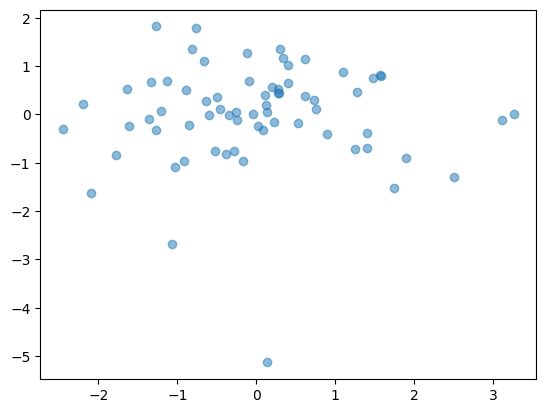

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)
plt.show()

In [11]:
X_test = build_min_vectors_by_slopes(df_test, N, take_all=True)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_test_scaled.shape

(980, 4)

In [30]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering.labels_[clustering.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_scaled, X_test_scaled[i - N], EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.4316, Recall: 0.6667, Precision: 0.0213, F1 Score: 0.0413, ROC_AUC: 0.5470


**KMeans**

In [31]:
from sklearn.cluster import KMeans

clustering = KMeans(n_clusters=2).fit(X_train_scaled)
clustering.labels_

array([0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1], dtype=int32)

In [36]:
def predict_kmeans(v, threshold=None):
    label = clustering.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test_scaled[i - N], threshold=EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.3796, Recall: 0.7778, Precision: 0.0227, F1 Score: 0.0440, ROC_AUC: 0.5750


prediction != -1

Accuracy: 0.6204, Recall: 0.2222, Precision: 0.0110, F1 Score: 0.0211, ROC_AUC: 0.4250

prediction == -1

Accuracy: 0.3796, Recall: 0.7778, Precision: 0.0227, F1 Score: 0.0440, ROC_AUC: 0.5750

***Максимумы***

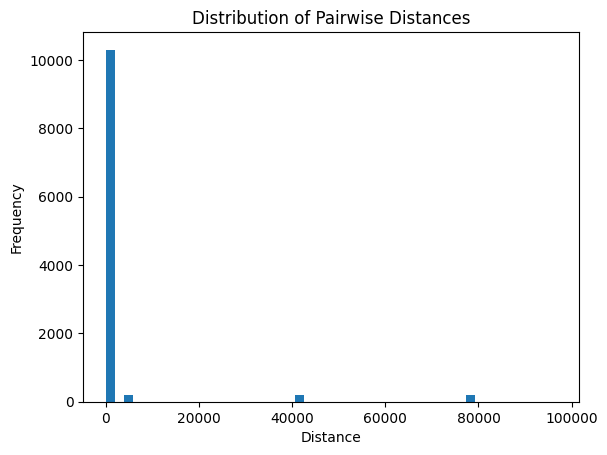

In [16]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_max)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [37]:
lower = np.percentile(X_train_max, 3, axis=0)
upper = np.percentile(X_train_max, 97, axis=0)
print("Lower percentiles (3%):", lower)
print("Upper percentiles (97%):", upper)

mask = np.all((X_train_max >= lower) & (X_train_max <= upper), axis=1)
X_train_clean = X_train_max[mask]

print(f"Осталось {mask.sum()} из {len(mask)} точек")

Lower percentiles (3%): [ -0.52674194 -13.75555712  -2.86760513   0.02203382]
Upper percentiles (97%): [0.37705937 7.39814773 2.20494418 7.22587526]
Осталось 77 из 105 точек


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

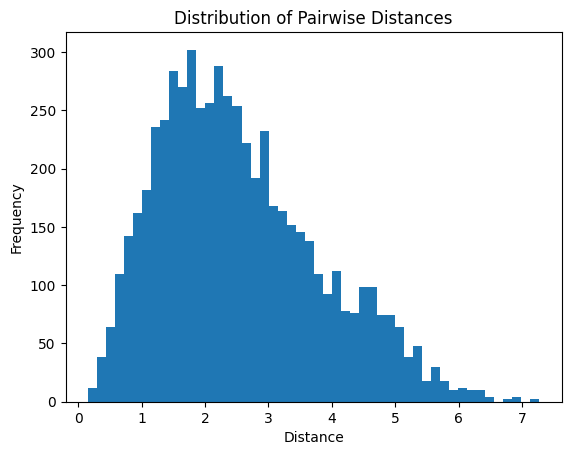

In [19]:
distances = euclidean_distances(X_train_scaled)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [20]:
print("Max values:")
print(np.max(X_train_scaled, axis=0))
print("Min values:")
print(np.min(X_train_scaled, axis=0))
print("Median values:")
print(np.median(X_train_scaled, axis=0))

Max values:
[2.3410605  3.1001172  3.19048775 4.28409388]
Min values:
[-2.99753209 -3.9533554  -3.6423919  -0.59874424]
Median values:
[ 0.06779354  0.13015802  0.09365346 -0.33484176]


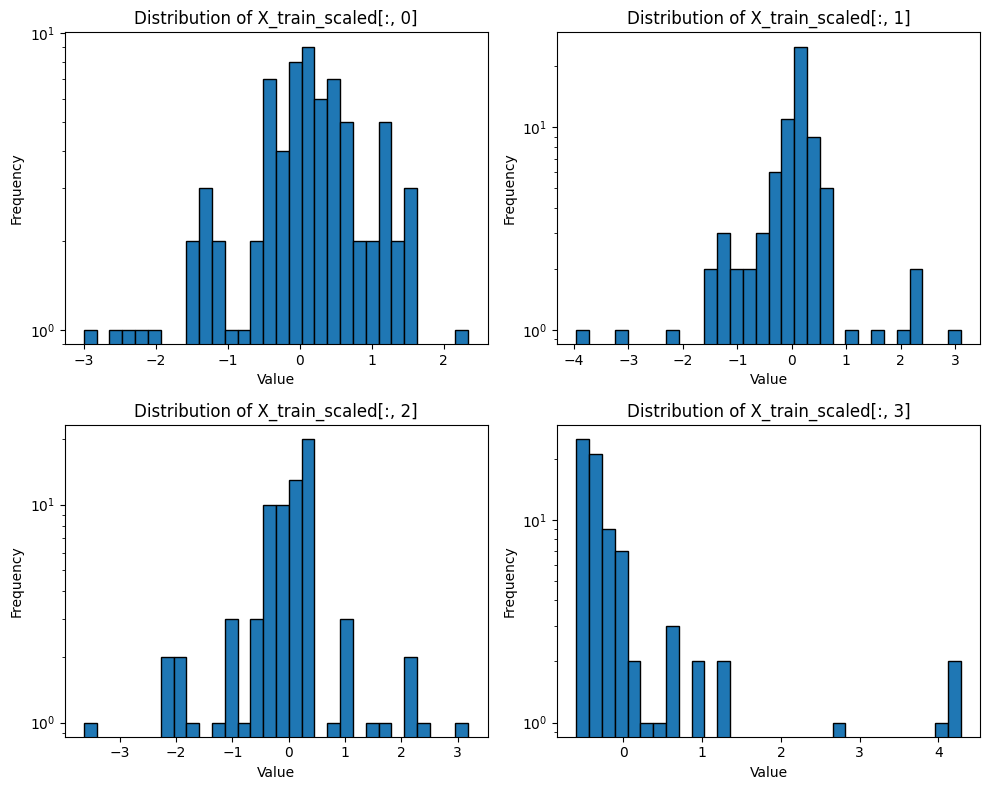

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].hist(X_train_scaled[:, i], bins=30, edgecolor='black')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of X_train_scaled[:, {i}]')
    axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

**DBSCAN**

In [39]:
from sklearn.cluster import DBSCAN

EPS = 1.5
clustering = DBSCAN(eps=EPS, min_samples=5).fit(X_train_scaled)
clustering.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0, -1,
        0, -1,  0,  0,  0, -1, -1,  0,  0])

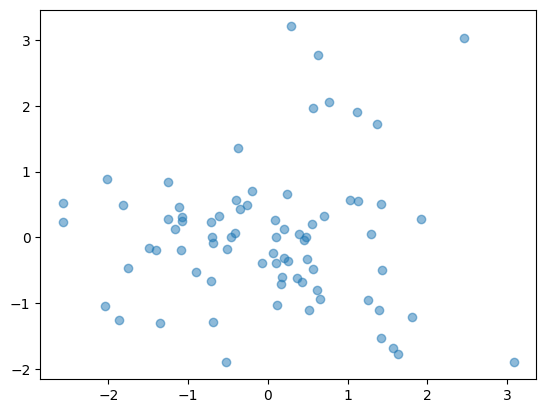

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)
plt.show()

In [42]:
def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering.labels_[clustering.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_scaled, X_test_scaled[i - N], EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.4153, Recall: 0.2727, Precision: 0.0107, F1 Score: 0.0205, ROC_AUC: 0.3457


Можно заметить интересное наблюдение. Если добавлять в y_pred (prediction != -1), то метрики следующие:

Accuracy: 0.4153, Recall: 0.2727, Precision: 0.0107, F1 Score: 0.0205, ROC_AUC: 0.3457

Если же инвертировать результат и добавлять (prediction == -1), то результат такой:

Accuracy: 0.5847, Recall: 0.7273, Precision: 0.0384, F1 Score: 0.0729, ROC_AUC: 0.6543

Можно сделать вывод, что модель предсказывает всё наоборот

**KMeans**

In [43]:
from sklearn.cluster import KMeans

clustering = KMeans(n_clusters=2).fit(X_train_scaled)
clustering.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], dtype=int32)

In [45]:
def predict_kmeans(v, threshold=None):
    label = clustering.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test_scaled[i - N], threshold=EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.2112, Recall: 0.9545, Precision: 0.0265, F1 Score: 0.0515, ROC_AUC: 0.5743
